<img src="https://walleigh.com/wp-content/uploads/2013/01/IMG_6589.jpg">

<p style="color: #FFFFFF; background-color: #420b31; text-align: center; font-weight: bold; font-size: 40px">
    Preliminaries
<p/>

**You may need the following:**
```python
pip install scikit-learn
pip install seaborn

```

<p style="color: #FFFFFF; background-color: #420b31; text-align: center; font-weight: bold; font-size: 20px">
    Part 1: Naive Bayes Classification for Two Classes
<p/>

# 1. Naive Bayes for Yes-No Classification


In [20]:
# Create a simple dataset

dict={'Weather': ['Sunny','Sunny','Overcast','Rainy','Rainy','Rainy','Overcast','Sunny','Sunny','Rainy','Sunny','Overcast','Overcast','Rainy'],
      'Temperature': ['Hot','Hot','Hot','Mild','Cool','Cool','Cool','Mild','Cool','Mild','Mild','Mild','Hot','Mild'],
      'Playing Golf':['No','No','Yes','Yes','Yes','No','Yes','No','Yes','Yes','Yes','Yes','Yes','No']}

In [21]:
import pandas as pd
from sklearn.naive_bayes import GaussianNB
from sklearn.preprocessing import LabelEncoder

In [22]:
df = pd.DataFrame(dict)

In [23]:
# Create the label encoder like every other model in scikit learn
le = LabelEncoder()

In [24]:
df['Weather Code'] = le.fit_transform(df['Weather'])
df['Temperature Code'] = le.fit_transform(df['Temperature'])
df['Playing Golf Code'] = le.fit_transform(df['Playing Golf'])
df

,Weather,Temperature,Playing Golf,Weather Code,Temperature Code,Playing Golf Code
0,Sunny,Hot,No,2,1,0
1,Sunny,Hot,No,2,1,0
2,Overcast,Hot,Yes,0,1,1
3,Rainy,Mild,Yes,1,2,1
4,Rainy,Cool,Yes,1,0,1
5,Rainy,Cool,No,1,0,0
6,Overcast,Cool,Yes,0,0,1
7,Sunny,Mild,No,2,2,0
8,Sunny,Cool,Yes,2,0,1
9,Rainy,Mild,Yes,1,2,1


In [25]:
# Split into X and y.
X = df[['Weather Code', 'Temperature Code']]
y = df['Playing Golf Code']

In [26]:
# Create the model
model = GaussianNB()

In [27]:
# Fit the model
model = model.fit(X, y)

In [28]:
# Make predictions
y_pred = model.predict(X)

output_df = pd.DataFrame(y_pred)
output_df['Observed'] = y
output_df.columns = ['Predicted', 'Observed']
output_df

,Predicted,Observed
0,0,0
1,0,0
2,1,1
3,1,1
4,1,1
5,1,0
6,1,1
7,0,0
8,0,1
9,1,1


In [29]:
# Accuracy of the model
print('The accuracy of the model: ', model.score(X, y))
from sklearn.metrics import accuracy_score
print('The accuracy of the model: ', accuracy_score(y_pred, y))

The accuracy of the model:  0.7142857142857143
The accuracy of the model:  0.7142857142857143


# 2. Naive Bayes with Multiple Labels (One set)

<p style="color: #FFFFFF; background-color: #420b31; text-align: center; font-weight: bold; font-size: 20px">
    Part 2: Naive Bayes Classification for Multiple Classes
<p/>

In [30]:
#Load dataset
from sklearn import datasets
winedata = datasets.load_wine()
dir(winedata)


['DESCR', 'data', 'feature_names', 'frame', 'target', 'target_names']

In [31]:
print(winedata.DESCR)

.. _wine_dataset:

Wine recognition dataset
------------------------

**Data Set Characteristics:**

    :Number of Instances: 178
    :Number of Attributes: 13 numeric, predictive attributes and the class
    :Attribute Information:
 		- Alcohol
 		- Malic acid
 		- Ash
		- Alcalinity of ash  
 		- Magnesium
		- Total phenols
 		- Flavanoids
 		- Nonflavanoid phenols
 		- Proanthocyanins
		- Color intensity
 		- Hue
 		- OD280/OD315 of diluted wines
 		- Proline

    - class:
            - class_0
            - class_1
            - class_2
		
    :Summary Statistics:
    
    ============================= ==== ===== ======= =====
                                   Min   Max   Mean     SD
    ============================= ==== ===== ======= =====
    Alcohol:                      11.0  14.8    13.0   0.8
    Malic Acid:                   0.74  5.80    2.34  1.12
    Ash:                          1.36  3.23    2.36  0.27
    Alcalinity of Ash:            10.6  30.0    19.5   3.3
    Ma

In [45]:
print(type(winedata.data))
print(type(winedata.target))
print(type(winedata.target_names))
print(type(winedata.feature_names))

print(winedata.data.shape)
print(winedata.target_names)
print(winedata.feature_names)

<class 'numpy.ndarray'>
<class 'numpy.ndarray'>
<class 'numpy.ndarray'>
<class 'list'>
(178, 13)
['class_0' 'class_1' 'class_2']
['alcohol', 'malic_acid', 'ash', 'alcalinity_of_ash', 'magnesium', 'total_phenols', 'flavanoids', 'nonflavanoid_phenols', 'proanthocyanins', 'color_intensity', 'hue', 'od280/od315_of_diluted_wines', 'proline']


In [33]:
# Create the variables
X = winedata.data
y = winedata.target

In [43]:
y

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2])

In [15]:
# Note: The data is already numeric, so we do not need the label encoder

In [16]:
# We plit the data into traing and test data
from sklearn.model_selection import train_test_split
y_train, y_test, X_train, X_test = train_test_split(y, X, train_size = 0.8, shuffle = True, random_state = 20)

In [17]:
from sklearn.naive_bayes import GaussianNB

In [18]:
# Create the model
model = GaussianNB()

In [19]:
# Fit the model
model = model.fit(X_train, y_train)

In [20]:
# Predictions on training set and test set
y_train_pred = model.predict(X_train)
y_test_pred = model.predict(X_test)

In [21]:
# Accuracy
print('Accuracy on training set: ', model.score(X_train, y_train))
print('Accuracy on test set: ', model.score(X_test, y_test))

Accuracy on training set:  0.971830985915493
Accuracy on test set:  1.0


In [22]:
# Visualization
from sklearn.metrics import confusion_matrix
from seaborn import heatmap
import matplotlib.pyplot as plt

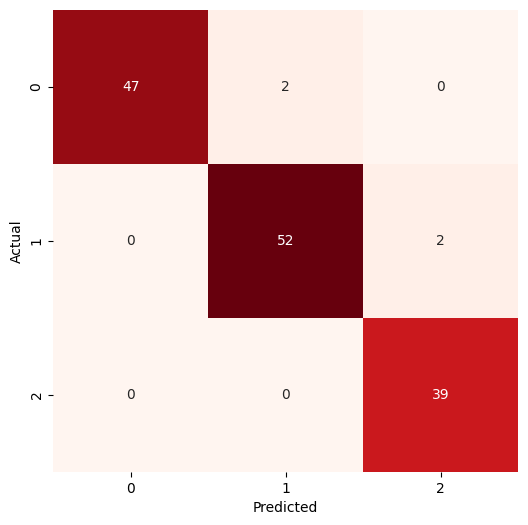

In [23]:
cm = confusion_matrix(y_train, y_train_pred)
plt.figure(figsize = (6, 6))
heatmap(cm, annot = True, cmap = 'Reds', cbar = False)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

In [24]:
# Check wether axes are correct
print(len(y_train[y_train == 0]))
print(len(y_train_pred[y_train_pred == 0]))

49
47


In [25]:
# Let us do this task simultainously for training and test
def Make_Heatmap(y, y_pred):
    cm = confusion_matrix(y, y_pred)
    plt.figure(figsize = (6, 6))
    heatmap(cm, annot = True, cmap = 'Reds', cbar = False)
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.show()

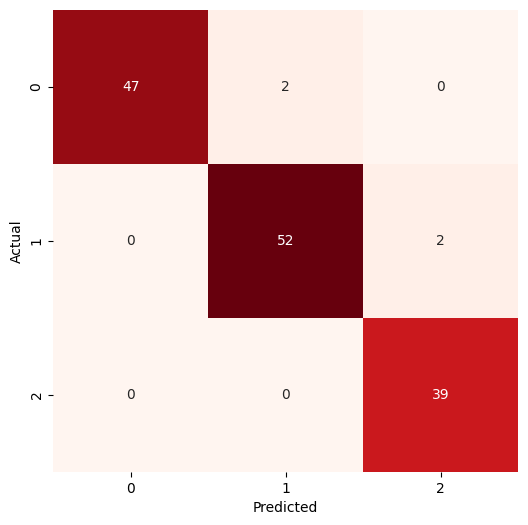

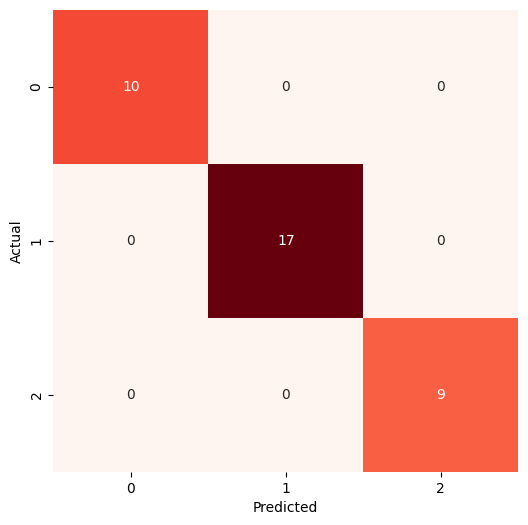

In [26]:
Make_Heatmap(y_train, y_train_pred)
Make_Heatmap(y_test, y_test_pred)

## The End